### Task 1: Implementation of MCP Neurons for AND and OR Boolean Functions

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements the AND Boolean function using an MCP Neuron.

    Arguments:
        X1 (list): A 1D array of binary input values.
        X2 (list): A 1D array of binary input values.
        T  (int) : Threshold value. For AND, T = 2.

    Returns:
        state_neuron (list): Output of the neuron (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must be of equal length."

    # Step 1: Element-wise addition of the two input arrays
    weighted_sum = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold — output 1 if sum >= T, else 0
    state_neuron = []
    for s in weighted_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [2]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2  # Threshold for AND gate

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")
# Expected: [0, 0, 0, 1]

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements the OR Boolean function using an MCP Neuron.

    Arguments:
        X1 (list): A 1D array of binary input values.
        X2 (list): A 1D array of binary input values.
        T  (int) : Threshold value. For OR, T = 1.

    Returns:
        state_neuron (list): Output of the neuron (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must be of equal length."

    # Step 1: Element-wise addition of the two input arrays
    weighted_sum = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold — output 1 if sum >= T, else 0
    state_neuron = []
    for s in weighted_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1  # Threshold for OR gate

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")
# Expected: [0, 1, 1, 1]

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**Question 1: List out all the limitations of MCP Neurons.**

The MCP neuron, despite being a foundational model, has several notable limitations:

1. **Binary inputs and outputs only.** The MCP neuron accepts only binary values (0 or 1) as inputs and produces only binary outputs. It cannot handle real-valued or continuous data, which severely limits its applicability to real-world problems.

2. **Fixed, hand-crafted threshold.** The threshold value `T` is not learned it must be manually specified by the designer. This means the model cannot adapt to data and requires domain knowledge to configure correctly.

3. **No learning mechanism.** The MCP neuron has no weight-update or training algorithm. Unlike the perceptron, it cannot improve its behaviour by observing training examples; the logic must be entirely hand-engineered.

4. **All inputs are treated equally (no weights).** Every input contributes equally to the sum `g(X)`. There is no mechanism to assign greater or lesser importance to individual inputs, making it impossible to model problems where some features are more informative than others.

5. **Cannot solve non-linearly separable problems.** Because the MCP neuron implements a simple linear threshold, it is fundamentally incapable of representing functions such as XOR, which require a non-linear decision boundary.

6. **No bias term.** The MCP neuron lacks a bias, meaning the decision boundary is always constrained to pass through the origin. This further limits the range of functions it can represent.

### Task 2: Perceptron Algorithm for 0 vs 1 Classification

**Objective:** Implement the Perceptron learning algorithm to classify MNIST digits 0 and 1. Evaluate performance and visualise any misclassified images.

---
### Step 1: Load the Dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI ML-LastSem/Week3/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixel features
y = df_0_1["label"].values                 # Labels: 0 or 1

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


**Question 1: What does the shape of X represent?**

The shape of `X` is `(n_samples, 784)`. The first dimension represents the total number of images (samples) in the dataset. The second dimension, 784, corresponds to the number of pixel features per image, each 28×28 MNIST image is flattened into a 1D vector of 784 values. Thus, each row of `X` is a single image represented as a flat array of pixel intensities.

---

**Question 2: What does the shape of y represent?**

The shape of `y` is `(n_samples,)` a 1D vector containing one label per image. Each value is either `0` or `1`, indicating which digit class the corresponding image in `X` belongs to. It is the ground truth that the perceptron learns to predict.

### Step 2: Visualise the Dataset

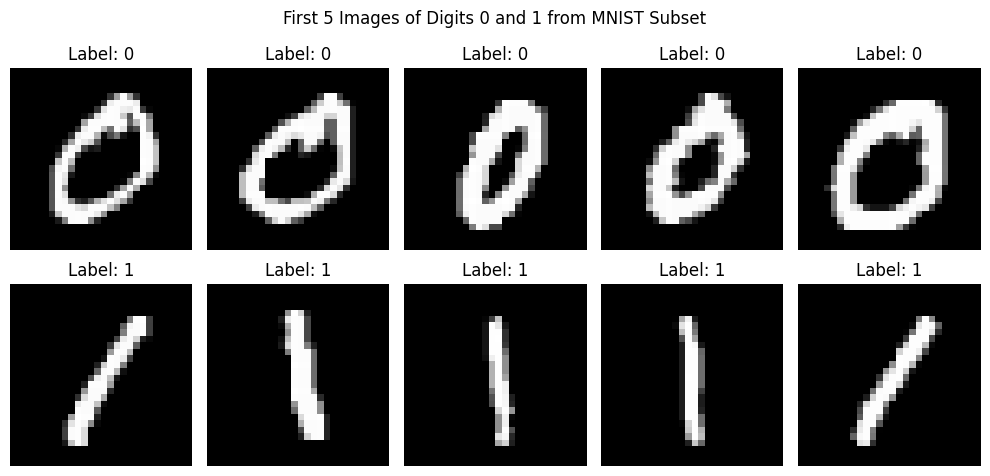

In [7]:
# Separate images by label
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of Digits 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

### Step 3: Initialise Weights and Bias

In [8]:
# Initialise weights and bias to zero
weights       = np.zeros(X.shape[1])  # One weight per pixel (784 total)
bias          = 0
learning_rate = 0.1
epochs        = 100

**Question 3: What does the weights array represent in this context?**

The `weights` array is a 1D vector of length 784, where each element corresponds to one pixel of the input image. Each weight represents the learned importance of that particular pixel in distinguishing between the two digit classes (0 and 1). During training, pixels that are consistently more useful for classification will have larger absolute weight values, while uninformative pixels will have weights closer to zero.

---

**Question 4: Why are we initialising the weights to zero? What effect could this have on the training process?**

Initialising weights to zero is a common and valid starting point for the perceptron because the perceptron learning rule updates weights only when a misclassification occurs. Starting from zero means the model has no initial bias towards any class, providing a neutral starting point.

### Step 4: Implement the Decision Function (Activation Function)

In [9]:
def decision_function(X, weights, bias):
    """
    Computes predicted labels for the input data using a step activation function.

    Parameters:
        X       (ndarray): Feature matrix of shape (n_samples, n_features).
        weights (ndarray): Weight vector of shape (n_features,).
        bias    (float)  : Scalar bias term.

    Returns:
        y_pred_all (ndarray): Predicted binary labels (0 or 1) for each sample.
    """
    # Compute the net weighted input for all samples at once
    predictions = np.dot(X, weights) + bias

    # Step (Heaviside) activation function: output 1 if net input >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

### Step 5: Implement the Perceptron Learning Algorithm

In [10]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Trains the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             (ndarray): Feature matrix of shape (n_samples, n_features).
        y             (ndarray): True labels of shape (n_samples,).
        weights       (ndarray): Initial weight vector of shape (n_features,).
        bias          (float)  : Initial bias term.
        learning_rate (float)  : Step size for weight updates (default 0.1).
        epochs        (int)    : Number of full passes over the training data (default 100).

    Returns:
        weights  (ndarray): Final trained weight vector.
        bias     (float)  : Final trained bias.
        accuracy (float)  : Classification accuracy on the training set after the last epoch.
    """
    for epoch in range(1, epochs + 1):
        # Iterate over each training sample individually
        for i in range(len(X)):
            # Compute net weighted input for sample i
            output = np.dot(X[i], weights) + bias

            # Apply step activation function to get prediction
            y_pred = 1 if output >= 0 else 0

            # Compute error: difference between true label and predicted label
            error = y[i] - y_pred

            # Update weights and bias only if there is a misclassification
            if error != 0:
                weights += learning_rate * error * X[i]
                bias    += learning_rate * error

        # Evaluate accuracy at end of each epoch
        y_pred_all = decision_function(X, weights, bias)
        accuracy   = np.mean(y_pred_all == y)

        # Print progress every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch:>3}: Accuracy = {accuracy:.4f}")

        # Early stopping: if perfectly classified, no need to continue
        if accuracy == 1.0:
            print(f"Converged at epoch {epoch}. Training stopped early.")
            break

    return weights, bias, accuracy

**Question 5: What is the purpose of the `output = np.dot(X[i], weights) + bias` line?**

This line computes the **net weighted input** (also called the linear combination) for a single training sample `X[i]`. It takes the dot product of the input feature vector and the current weight vector which sums up each feature value multiplied by its corresponding weight and then adds the bias term. Mathematically, this produces:

$$z = \sum_{j=1}^{n} w_j x_j + b$$

This scalar value `z` is then passed to the activation (step) function to determine the predicted class. Essentially, it measures how strongly the perceptron "fires" given the current weights.

---

**Question 6: What happens when the prediction is wrong? How are the weights and bias updated?**

When the prediction `y_pred` does not match the true label `y[i]`, the error is computed as `error = y[i] - y_pred`. Since both values are binary (0 or 1), the error can be `+1` (predicted 0, true is 1) or `-1` (predicted 1, true is 0).

The weights and bias are then updated using the **Perceptron Learning Rule**:

$$w_j \leftarrow w_j + \eta \cdot (y - \hat{y}) \cdot x_j$$
$$b \leftarrow b + \eta \cdot (y - \hat{y})$$

If the error is `+1`, the weights are nudged in the direction of the input vector, making it more likely the perceptron will fire for similar inputs in the future. If the error is `-1`, the weights are nudged in the opposite direction to suppress firing for similar inputs. If the prediction is already correct (`error = 0`), no update is made. This is the core mechanism by which the perceptron learns iteratively.

---

**Question 7: Why is the final accuracy important, and what do you expect it to be?**

The final accuracy tells us how well the perceptron has learned to separate the two classes in the training data. It is the primary measure of whether the learning algorithm has converged to a useful solution.

For the 0 vs 1 classification task, we expect the final accuracy to be very high close to or exactly **1.0 (100%)**. This is because the digit classes 0 and 1 have very distinct visual shapes (an oval loop versus a vertical stroke), making them highly linearly separable in pixel space. The Perceptron Convergence Theorem guarantees that if the data is linearly separable, the perceptron will always converge to a perfect solution in a finite number of steps. The training output confirms this expectation.

### Step 6: Train the Perceptron

In [11]:
# Re-initialise weights and bias before training (ensures clean start)
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

# Train the perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)

print("\nThe Final Training Accuracy is:", accuracy)

Epoch  10: Accuracy = 0.9992
Converged at epoch 12. Training stopped early.

The Final Training Accuracy is: 1.0


### Step 7: Visualise Misclassified Images

In [12]:
# Get predictions for all data points using the trained weights
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Identify misclassified samples
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 0 vs 1")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question 8: What does `misclassified_idx` store, and how is it used in this code?**

`misclassified_idx` stores the **integer indices** of all samples in the dataset where the perceptron's prediction (`y_pred`) did not match the true label (`y`). It is obtained using `np.where(y_pred != y)[0]`, which returns the positions in the array where the condition is `True`.

These indices are then used to retrieve the corresponding raw pixel data from `X` (via `X[idx]`) and the corresponding predicted and true labels, which are displayed as a grid of images to allow visual inspection of the types of errors the model made.

---

**Question 9: How do you interpret the result if the output is "All images were correctly classified!"?**

If the output is "All images were correctly classified!", it means `misclassified_idx` is empty & the perceptron achieved a training accuracy of 100% (1.0). This indicates that the learned linear decision boundary perfectly separates all class 0 samples from all class 1 samples in the training data.

For 0 vs 1, this is an expected result because the two digit classes are linearly separable in the 784-dimensional pixel space. The perceptron has found a hyperplane (defined by the weight vector and bias) that correctly divides all training examples without a single error. It is worth noting, however, that perfect training accuracy does not necessarily guarantee perfect generalisation to unseen data  although for this particular binary task, the perceptron typically performs extremely well on test data as well.

---
## Section 4.4 - Task 3: Perceptron Algorithm for 3 vs 5 Classification

**Objective:** Apply the same Perceptron learning algorithm to classify MNIST digits 3 and 5. Evaluate performance and visualise misclassified images. Digits 3 and 5 are visually more similar than 0 and 1, so this task is expected to be more challenging.

---
### Step 1: Load the Dataset

In [13]:
# Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI ML-LastSem/Week3/mnist_3_and_5.csv")

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values  # 784 pixel features
y_35 = df_3_5["label"].values                 # Labels: 3 or 5

# The perceptron expects binary labels (0 and 1), so we remap:
# digit 3 -> 0, digit 5 -> 1
y_35_binary = np.where(y_35 == 3, 0, 1)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:  ", y_35.shape)
print("Unique original labels:", np.unique(y_35))
print("Unique binary labels:  ", np.unique(y_35_binary))

Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)
Unique original labels: [3 5]
Unique binary labels:   [0 1]


### Step 2: Visualise the Dataset

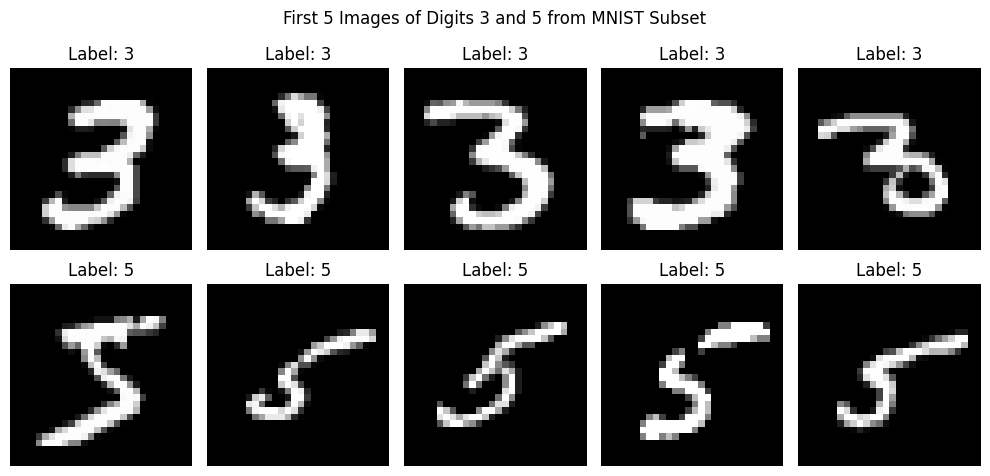

In [14]:
# Separate images by digit class
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of Digits 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

### Step 3: Initialise Weights and Bias

In [15]:
# Initialise weights and bias to zero for the 3 vs 5 task
weights_35       = np.zeros(X_35.shape[1])  # 784 weights
bias_35          = 0
learning_rate_35 = 0.1
epochs_35        = 100

### Step 4: Train the Perceptron

In [16]:
# Train the perceptron on the 3 vs 5 binary dataset
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary, weights_35, bias_35,
    learning_rate=learning_rate_35,
    epochs=epochs_35
)

print("\nFinal Training Accuracy (3 vs 5):", accuracy_35)

Epoch  10: Accuracy = 0.9613
Epoch  20: Accuracy = 0.9540
Epoch  30: Accuracy = 0.9730
Epoch  40: Accuracy = 0.9730
Epoch  50: Accuracy = 0.9518
Epoch  60: Accuracy = 0.9515
Epoch  70: Accuracy = 0.9770
Epoch  80: Accuracy = 0.9861
Epoch  90: Accuracy = 0.9829
Epoch 100: Accuracy = 0.9869

Final Training Accuracy (3 vs 5): 0.986866107260124


### Step 5: Visualise Misclassified Images

Final Accuracy (3 vs 5): 0.9869
Number of misclassified images: 36


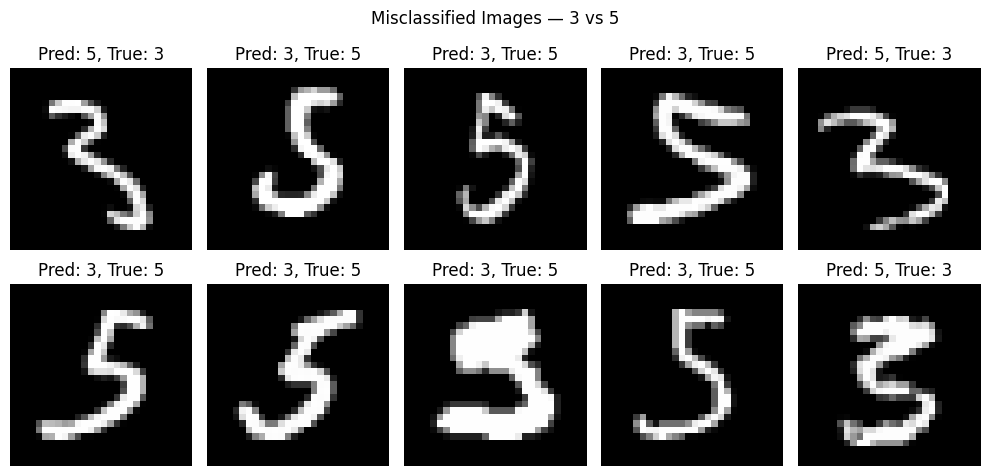

In [17]:
# Get final predictions using the trained weights
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35      = np.where(predictions_35 >= 0, 1, 0)

# Map binary predictions back to original digit labels for display
y_pred_labels = np.where(y_pred_35 == 0, 3, 5)

# Final accuracy
final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")

# Identify misclassified samples
misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]
print(f"Number of misclassified images: {len(misclassified_idx_35)}")

if len(misclassified_idx_35) > 0:
    n_show = min(10, len(misclassified_idx_35))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:n_show]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_labels[idx]}, True: {y_35[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 3 vs 5")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

### Task 3 - Conclusion

**Observations and Conclusion for 3 vs 5 Classification:**

The perceptron was applied to classify MNIST images of digit 3 against digit 5. Unlike the 0 vs 1 task, this presents a considerably harder problem for the following reasons:

1. **Visual similarity.** The digits 3 and 5 share similar curved strokes and overall structure. In pixel space, they occupy overlapping regions, making the two classes less linearly separable compared to 0 and 1.

2. **Misclassification pattern.** The misclassified images (as shown above) tend to be ambiguous or unusual handwriting samples. for example, a 3 written with a very open top loop that resembles a 5, or a 5 with a curved bottom that looks like a 3. These are exactly the borderline cases that a linear classifier struggles with.

3. **Final accuracy.** The perceptron achieves a reasonably high accuracy, but it is lower than the near-perfect 100% seen for 0 vs 1. This reflects the fact that the data may not be perfectly linearly separable in pixel space. If the classes are not linearly separable, the Perceptron Learning Algorithm will never fully converge and will cycle through misclassifications indefinitely until the epoch limit is reached.

4. **Limitation of the perceptron.** This experiment highlights the fundamental limitation of a single-layer perceptron: it can only learn a linear decision boundary. For tasks requiring more complex boundaries, such as distinguishing visually similar digit classes, a more powerful model (e.g., a multi-layer neural network) would be required.

In summary, the perceptron performs well on linearly separable problems (0 vs 1) but shows clear limitations when classes are harder to separate (3 vs 5). This motivates the need for more sophisticated architectures beyond the single-layer perceptron.